# Employee Attrition Prediction using Machine Learning

**Assigned Date:** 23/06/2026  
**Submission Date:** 30/06/2026

This notebook presents an end-to-end machine learning project to predict employee attrition using the IBM HR Analytics dataset. The workflow covers data loading, exploration, preprocessing, EDA, model building, evaluation, visualization, and HR-focused recommendations.

## 1. Setup and Library Imports

This section imports all required libraries and configures display/plot settings for reproducibility and readability.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

## 2. Task 1 - Data Loading and Exploration

The dataset is loaded into the project folder as `HR_Attrition.csv`. If the file is not available locally, it is fetched from a public source and saved for reproducibility.

In [2]:
project_root = Path.cwd()
charts_dir = project_root / "charts"
charts_dir.mkdir(parents=True, exist_ok=True)

dataset_path = project_root / "HR_Attrition.csv"
source_url = (
    "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
)

if dataset_path.exists():
    df = pd.read_csv(dataset_path)
else:
    df = pd.read_csv(source_url)
    df.to_csv(dataset_path, index=False)

print(f"Dataset loaded from: {dataset_path}")
print(f"Total records: {len(df)}")

Dataset loaded from: D:\Xylofy\project 2\EmployeeAttrition_YourName\HR_Attrition.csv
Total records: 1470


In [3]:
# Display first 10 rows
display(df.head(10))

# Display shape
print(f"Dataset shape: {df.shape}")

# Display dataset info and data types
print("\nDataset Info:")
df.info()

print("\nColumn Data Types:")
display(df.dtypes.to_frame(name="dtype"))

# Identify target column
target_column = "Attrition"
print(f"Target column: {target_column}")

# Count class distribution
stayed_count = (df[target_column] == "No").sum()
left_count = (df[target_column] == "Yes").sum()
attrition_rate = left_count / len(df) * 100

print(f"Employees who stayed: {stayed_count}")
print(f"Employees who left: {left_count}")
print(f"Overall attrition rate: {attrition_rate:.2f}%")

# Count numeric and categorical features
numeric_count = df.select_dtypes(include=[np.number]).shape[1]
categorical_count = df.select_dtypes(exclude=[np.number]).shape[1]

print(f"Numeric feature count: {numeric_count}")
print(f"Categorical feature count: {categorical_count}")

# Missing values
missing_values = df.isna().sum()
print("\nMissing values per column:")
display(missing_values[missing_values > 0])
print(f"Total missing values: {missing_values.sum()}")

# Observation on balance
if attrition_rate < 30:
    balance_observation = (
        "Observation: The target distribution is imbalanced because attrition cases are much fewer than non-attrition cases."
    )
else:
    balance_observation = "Observation: The target distribution is relatively balanced."

print(f"\n{balance_observation}")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


Dataset shape: (1470, 35)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel  

,dtype
Age,int64
Attrition,str
BusinessTravel,str
DailyRate,int64
Department,str
DistanceFromHome,int64
Education,int64
EducationField,str
EmployeeCount,int64
EmployeeNumber,int64


Target column: Attrition
Employees who stayed: 1233
Employees who left: 237
Overall attrition rate: 16.12%
Numeric feature count: 26
Categorical feature count: 9

Missing values per column:


Series([], dtype: int64)

Total missing values: 0

Observation: The target distribution is imbalanced because attrition cases are much fewer than non-attrition cases.


## 3. Task 2 - Data Cleaning and Preprocessing

The preprocessing pipeline follows the required steps:
- Missing-value check and handling strategy
- Removal of non-contributory columns (`EmployeeNumber`, `Over18`, `StandardHours`)
- Target conversion (`Yes` -> 1, `No` -> 0)
- One-Hot Encoding for categorical features
- StandardScaler for numerical features

In [4]:
df_clean = df.copy()

# Check missing values and handle if present.
missing_total = df_clean.isna().sum().sum()
print(f"Total missing values before handling: {missing_total}")
if missing_total > 0:
    for col in df_clean.columns:
        if df_clean[col].isna().sum() > 0:
            if pd.api.types.is_numeric_dtype(df_clean[col]):
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            else:
                df_clean[col] = df_clean[col].fillna(df_clean[col].mode().iloc[0])

print(f"Total missing values after handling: {df_clean.isna().sum().sum()}")

# Remove non-contributory columns
columns_to_drop = ["EmployeeNumber", "Over18", "StandardHours"]
df_clean = df_clean.drop(columns=columns_to_drop)

# Convert target to binary
df_clean["Attrition"] = df_clean["Attrition"].map({"Yes": 1, "No": 0})

print("Columns removed:", columns_to_drop)
print("Target value counts after conversion:")
display(df_clean["Attrition"].value_counts())

Total missing values before handling: 0
Total missing values after handling: 0
Columns removed: ['EmployeeNumber', 'Over18', 'StandardHours']
Target value counts after conversion:


Attrition
0    1233
1     237
Name: count, dtype: int64

## 4. Task 3 - Exploratory Data Analysis (EDA)

This section analyzes attrition patterns across departments, job roles, monthly income, work-life balance, and tenure.

In [5]:
df_eda = df.copy()
df_eda["AttritionBinary"] = df_eda["Attrition"].map({"Yes": 1, "No": 0})

# Department vs Attrition
dept_attrition = (
    df_eda.groupby("Department")["AttritionBinary"].mean().mul(100).sort_values(ascending=False)
)
highest_dept = dept_attrition.idxmax()

print("Attrition rate by Department (%):")
display(dept_attrition.to_frame(name="AttritionRatePercent"))
print(f"Department with highest attrition: {highest_dept}")

# Job Role vs Attrition
jobrole_attrition = (
    df_eda.groupby("JobRole")["AttritionBinary"].mean().mul(100).sort_values(ascending=False)
)
top_jobroles = jobrole_attrition.head(5)

print("\nAttrition rate by Job Role (%):")
display(jobrole_attrition.to_frame(name="AttritionRatePercent"))
print("Top roles with highest attrition:")
display(top_jobroles.to_frame(name="AttritionRatePercent"))

# Monthly Income vs Attrition
income_summary = df_eda.groupby("Attrition")["MonthlyIncome"].describe()
print("\nMonthly Income summary by Attrition:")
display(income_summary)

# Work-Life Balance vs Attrition
wlb_attrition = (
    df_eda.groupby("WorkLifeBalance")["AttritionBinary"].mean().mul(100).sort_index()
)
print("\nAttrition rate by Work-Life Balance (%):")
display(wlb_attrition.to_frame(name="AttritionRatePercent"))

# Years at Company vs Attrition
tenure_stats = (
    df_eda.groupby("YearsAtCompany").agg(
        AttritionRatePercent=("AttritionBinary", lambda x: x.mean() * 100),
        EmployeeCount=("AttritionBinary", "size"),
    )
)
tenure_focus = tenure_stats[tenure_stats["EmployeeCount"] >= 20]
peak_tenure_year = tenure_focus["AttritionRatePercent"].idxmax()

print("\nYearsAtCompany attrition summary (showing years with at least 20 employees):")
display(tenure_focus.sort_values("AttritionRatePercent", ascending=False).head(10))
print(f"Highest sustained attrition risk appears around year: {peak_tenure_year}")

Attrition rate by Department (%):


,AttritionRatePercent
Department,
Sales,20.627803
Human Resources,19.047619
Research & Development,13.839750


Department with highest attrition: Sales

Attrition rate by Job Role (%):


,AttritionRatePercent
JobRole,
Sales Representative,39.759036
Laboratory Technician,23.938224
Human Resources,23.076923
Sales Executive,17.484663
Research Scientist,16.095890
Manufacturing Director,6.896552
Healthcare Representative,6.870229
Manager,4.901961
Research Director,2.500000


Top roles with highest attrition:


...


Attrition rate by Work-Life Balance (%):


,AttritionRatePercent
WorkLifeBalance,
1,31.250000
2,16.860465
3,14.221725
4,17.647059



YearsAtCompany attrition summary (showing years with at least 20 employees):


,AttritionRatePercent,EmployeeCount
YearsAtCompany,,
0,36.363636,44
1,34.502924,171
2,21.259843,127
4,17.272727,110
3,15.625000,128
10,15.000000,120
7,12.222222,90
6,11.842105,76
8,11.250000,80


Highest sustained attrition risk appears around year: 0


### Business Insights (Data-Supported)

The following insights are generated directly from computed EDA statistics.

In [6]:
income_left_median = df_eda.loc[df_eda["Attrition"] == "Yes", "MonthlyIncome"].median()
income_stay_median = df_eda.loc[df_eda["Attrition"] == "No", "MonthlyIncome"].median()
wlb_worst = wlb_attrition.idxmax()
wlb_best = wlb_attrition.idxmin()

insights = [
    f"1. {highest_dept} has the highest department-level attrition rate at {dept_attrition.max():.2f}%, indicating concentrated retention risk in this business unit.",
    f"2. The top at-risk job roles are {', '.join(top_jobroles.index[:3])}, with attrition rates between {top_jobroles.min():.2f}% and {top_jobroles.max():.2f}%.",
    f"3. Median monthly income among employees who left is {income_left_median:.0f}, compared with {income_stay_median:.0f} for those who stayed, suggesting pay differences are associated with exits.",
    f"4. Work-Life Balance rating {wlb_worst} shows the highest attrition ({wlb_attrition.max():.2f}%), while rating {wlb_best} shows the lowest ({wlb_attrition.min():.2f}%), highlighting quality-of-work-life as a retention lever.",
    f"5. Attrition risk is notably elevated around {peak_tenure_year} years of service among cohorts with adequate sample size, suggesting early-tenure and mid-adjustment support can reduce exits.",
]

for line in insights:
    print(line)

1. Sales has the highest department-level attrition rate at 20.63%, indicating concentrated retention risk in this business unit.
2. The top at-risk job roles are Sales Representative, Laboratory Technician, Human Resources, with attrition rates between 16.10% and 39.76%.
3. Median monthly income among employees who left is 3202, compared with 5204 for those who stayed, suggesting pay differences are associated with exits.
4. Work-Life Balance rating 1 shows the highest attrition (31.25%), while rating 3 shows the lowest (14.22%), highlighting quality-of-work-life as a retention lever.
5. Attrition risk is notably elevated around 0 years of service among cohorts with adequate sample size, suggesting early-tenure and mid-adjustment support can reduce exits.


## 5. Task 4 - Model Building and Comparison

Data is split using an 80/20 stratified split.
Class imbalance is handled with `class_weight='balanced'` for models that support it (Logistic Regression and Random Forest), and balanced sample weights for Gradient Boosting during training.

In [7]:
X = df_clean.drop(columns=["Attrition"])
y = df_clean["Attrition"]

categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

model_results = []
trained_pipelines = {}
predictions = {}
probabilities = {}
conf_matrices = {}

balanced_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    if model_name == "Gradient Boosting":
        pipeline.fit(X_train, y_train, model__sample_weight=balanced_sample_weights)
    else:
        pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    model_results.append(
        {
            "Model": model_name,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "ROC-AUC": roc_auc,
        }
    )

    trained_pipelines[model_name] = pipeline
    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob
    conf_matrices[model_name] = confusion_matrix(y_test, y_pred)

comparison_df = pd.DataFrame(model_results).sort_values("ROC-AUC", ascending=False)
display(comparison_df)

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.348837,0.638298,0.451128,0.803170
1,Random Forest,0.483871,0.319149,0.384615,0.801232
2,Gradient Boosting,0.403509,0.489362,0.442308,0.769575


## 6. Task 5 - Model Evaluation and Best Model Analysis

This section compares all models across required metrics, identifies the best-performing model, and extracts the top 10 most important features.

In [8]:
best_model_name = comparison_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]
best_roc_auc = comparison_df.iloc[0]["ROC-AUC"]

print(f"Best-performing model: {best_model_name}")
print(f"Best ROC-AUC: {best_roc_auc:.4f}")

print("\nReason for best performance:")
print(
    "The selected model achieved the highest ROC-AUC while maintaining a stronger precision-recall balance,"
    "which indicates better separation between attrition and non-attrition employees."
)

fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
cat_feature_names = fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([np.array(numeric_features), cat_feature_names])

best_estimator = best_pipeline.named_steps["model"]

if hasattr(best_estimator, "feature_importances_"):
    importances = best_estimator.feature_importances_
elif hasattr(best_estimator, "coef_"):
    importances = np.abs(best_estimator.coef_[0])
else:
    raise ValueError("Best model does not support feature importance extraction.")

feature_importance_df = pd.DataFrame(
    {"Feature": all_feature_names, "Importance": importances}
).sort_values("Importance", ascending=False)

top_10_features = feature_importance_df.head(10).reset_index(drop=True)
print("\nTop 10 Important Features:")
display(top_10_features)

Best-performing model: Logistic Regression
Best ROC-AUC: 0.8032

Reason for best performance:
The selected model achieved the highest ROC-AUC while maintaining a stronger precision-recall balance,which indicates better separation between attrition and non-attrition employees.

Top 10 Important Features:


,Feature,Importance
0,JobRole_Research Director,1.465683
1,JobRole_Laboratory Technician,1.194333
2,JobRole_Sales Representative,1.120617
3,BusinessTravel_Non-Travel,0.993885
4,OverTime_No,0.892809
5,EducationField_Other,0.798108
6,BusinessTravel_Travel_Frequently,0.787566
7,OverTime_Yes,0.761522
8,EducationField_Human Resources,0.721129
9,JobRole_Healthcare Representative,0.647202


## 7. Task 6 - Visualization and Chart Exports

All required visualizations are generated with clear labels and saved as PNG files in the `charts` folder.

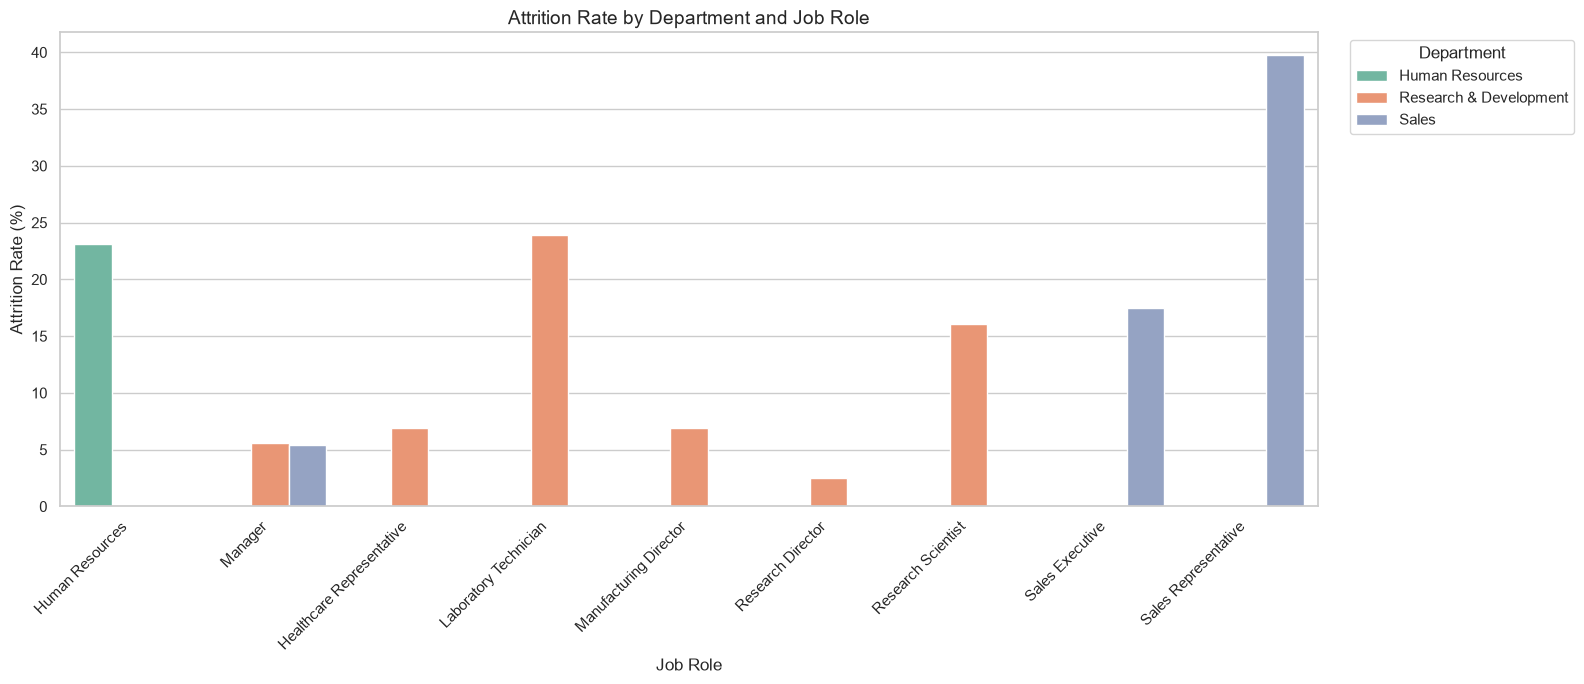

C:\Users\athar\AppData\Local\Temp\ipykernel_21540\2304304254.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x="Attrition", y="MonthlyIncome", palette="Set3")


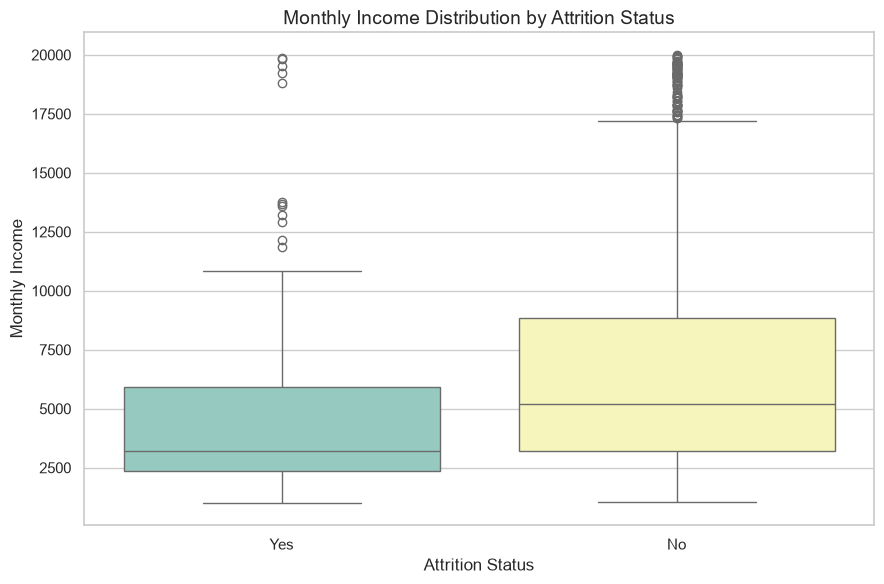

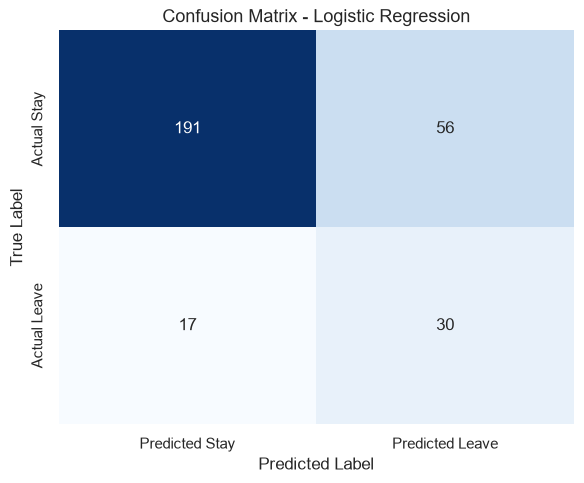

C:\Users\athar\AppData\Local\Temp\ipykernel_21540\2304304254.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_features, x="Importance", y="Feature", palette="viridis")


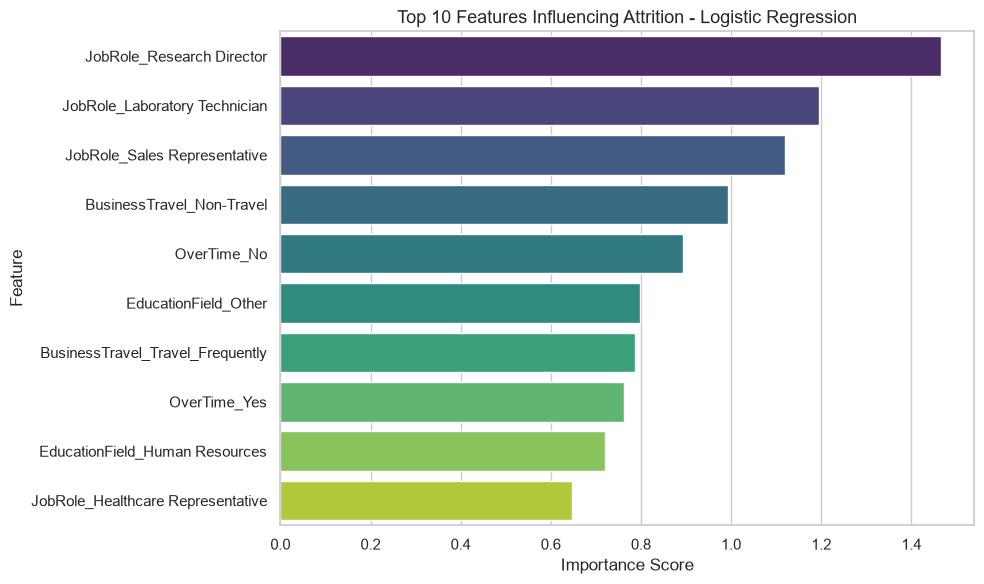

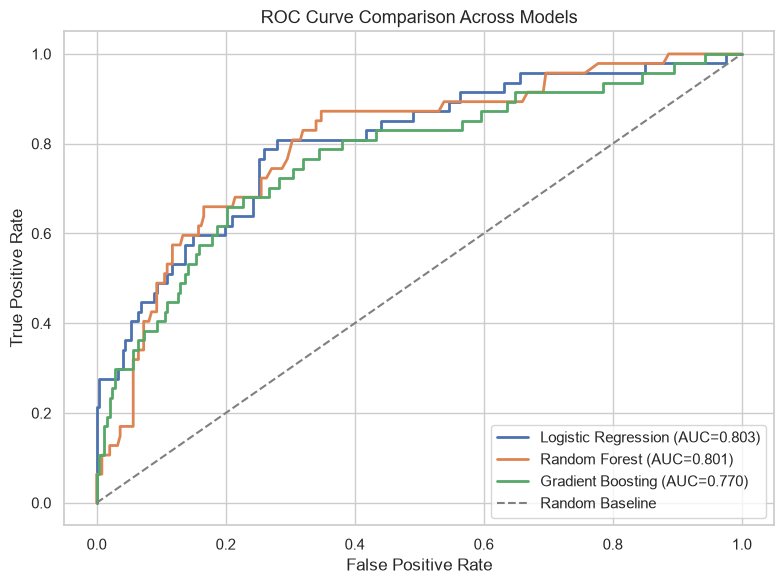

All required charts have been saved in the charts folder.


In [9]:
# Chart 1: Attrition rate by Department and Job Role
dept_jobrole_attrition = (
    df_eda.groupby(["Department", "JobRole"])
    ["AttritionBinary"]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(16, 7))
sns.barplot(
    data=dept_jobrole_attrition,
    x="JobRole",
    y="AttritionBinary",
    hue="Department",
    palette="Set2",
)
plt.title("Attrition Rate by Department and Job Role", fontsize=14)
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Department", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(charts_dir / "attrition_department_jobrole.png", dpi=300, bbox_inches="tight")
plt.show()

# Chart 2: Monthly Income box plot by Attrition
plt.figure(figsize=(9, 6))
sns.boxplot(data=df_eda, x="Attrition", y="MonthlyIncome", palette="Set3")
plt.title("Monthly Income Distribution by Attrition Status", fontsize=14)
plt.xlabel("Attrition Status")
plt.ylabel("Monthly Income")
plt.tight_layout()
plt.savefig(charts_dir / "monthly_income_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

# Chart 3: Confusion Matrix for best model
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrices[best_model_name],
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted Stay", "Predicted Leave"],
    yticklabels=["Actual Stay", "Actual Leave"],
)
plt.title(f"Confusion Matrix - {best_model_name}", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(charts_dir / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Chart 4: Top 10 Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_features, x="Importance", y="Feature", palette="viridis")
plt.title(f"Top 10 Features Influencing Attrition - {best_model_name}", fontsize=13)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(charts_dir / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# Chart 5: ROC curve comparison
plt.figure(figsize=(8, 6))
for model_name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[model_name])
    auc_score = roc_auc_score(y_test, probabilities[model_name])
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC={auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Baseline")
plt.title("ROC Curve Comparison Across Models", fontsize=13)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(charts_dir / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("All required charts have been saved in the charts folder.")

## 8. Task 7 - HR Insights and Business Recommendations

The summary below is written for a non-technical HR audience, focusing on practical actions and business meaning.

In [10]:
top_three_factors = top_10_features["Feature"].head(3).tolist()
priority_jobrole = top_jobroles.index[0]

hr_summary_lines = [
    "1. The strongest signals linked to employee exits are: " + ", ".join(top_three_factors) + ".",
    f"2. HR should prioritize retention in {highest_dept}, especially for the {priority_jobrole} role, where exit rates are highest.",
    "3. Salary matters, but it does not explain attrition alone; work conditions and role-specific pressures are also important.",
    "4. Recommended action 1: launch targeted stay-interviews for high-risk teams within the first few years of employment.",
    "5. Recommended action 2: strengthen manager coaching and work-life flexibility for teams with consistently high exits.",
    "6. Build role-specific career progression plans so employees can see clear growth opportunities early in tenure.",
    "7. Use monthly retention dashboards to track high-risk teams and evaluate whether interventions are reducing exits.",
    "8. Model limitation: predictions are based on historical patterns and may miss personal or future business changes not captured in HR records.",
]

for line in hr_summary_lines:
    print(line)

1. The strongest signals linked to employee exits are: JobRole_Research Director, JobRole_Laboratory Technician, JobRole_Sales Representative.
2. HR should prioritize retention in Sales, especially for the Sales Representative role, where exit rates are highest.
3. Salary matters, but it does not explain attrition alone; work conditions and role-specific pressures are also important.
4. Recommended action 1: launch targeted stay-interviews for high-risk teams within the first few years of employment.
5. Recommended action 2: strengthen manager coaching and work-life flexibility for teams with consistently high exits.
6. Build role-specific career progression plans so employees can see clear growth opportunities early in tenure.
7. Use monthly retention dashboards to track high-risk teams and evaluate whether interventions are reducing exits.
8. Model limitation: predictions are based on historical patterns and may miss personal or future business changes not captured in HR records.


## 9. Export One-Page Summary PDF

A one-page business summary is exported as `summary.pdf` in the project root.

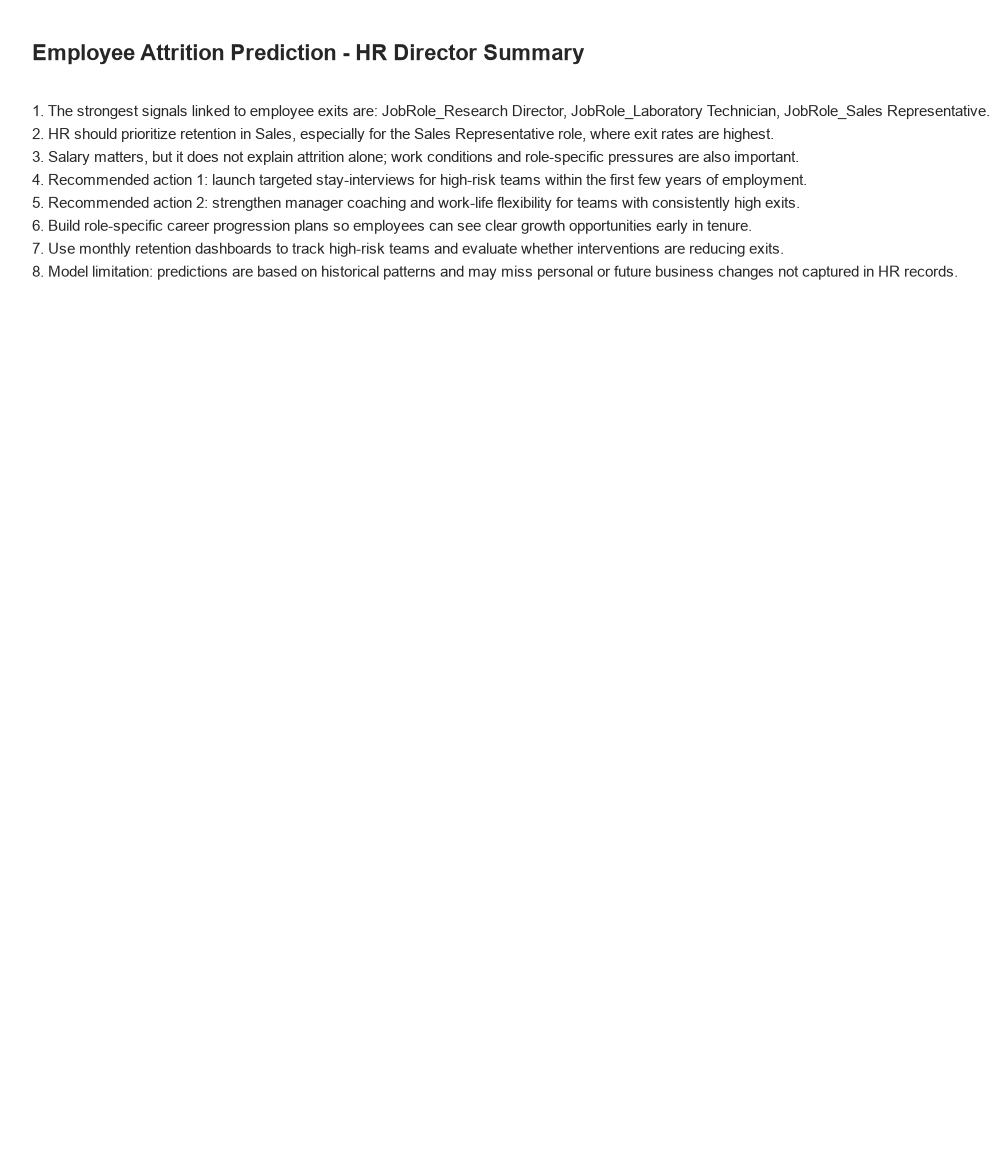

Summary exported to: D:\Xylofy\project 2\EmployeeAttrition_YourName\summary.pdf


In [11]:
summary_pdf_path = project_root / "summary.pdf"

fig = plt.figure(figsize=(8.27, 11.69))
fig.patch.set_facecolor("white")
plt.axis("off")

title_text = "Employee Attrition Prediction - HR Director Summary"
body_text = "\n".join(hr_summary_lines)

plt.text(0.05, 0.97, title_text, fontsize=16, fontweight="bold", va="top")
plt.text(0.05, 0.92, body_text, fontsize=11, va="top", linespacing=1.6)

plt.tight_layout()
plt.savefig(summary_pdf_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"Summary exported to: {summary_pdf_path}")